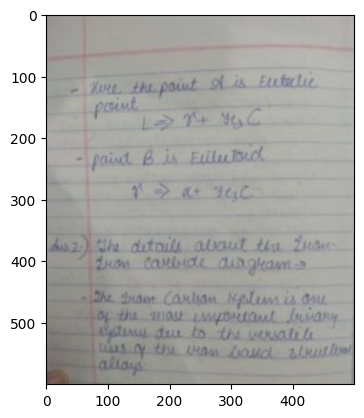

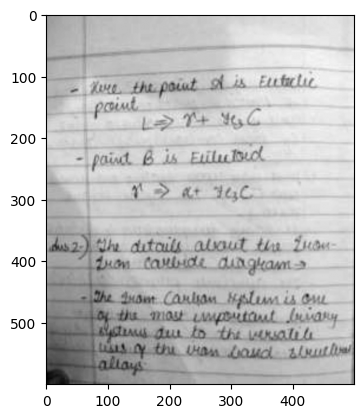

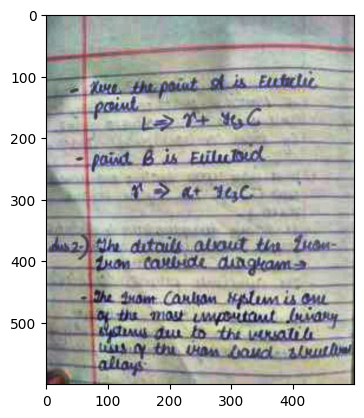

0
[[[127 130 109]
  [127 130 109]
  [122 125 103]
  ...
  [161 156 160]
  [155 151 154]
  [155 151 154]]

 [[127 130 109]
  [127 130 109]
  [122 125 103]
  ...
  [161 156 160]
  [155 151 154]
  [155 151 154]]

 [[127 130 109]
  [127 130 109]
  [122 125 103]
  ...
  [161 156 160]
  [155 151 154]
  [155 151 154]]

 ...

 [[ 47  31  80]
  [ 47  31  80]
  [ 47  31  75]
  ...
  [ 73  87  92]
  [ 70  83  87]
  [ 66  78  83]]

 [[ 42  28  75]
  [ 42  28  75]
  [ 47  31  80]
  ...
  [ 73  87  92]
  [ 70  83  87]
  [ 66  78  83]]

 [[ 42  28  75]
  [ 42  28  75]
  [ 47  31  80]
  ...
  [ 73  87  92]
  [ 70  83  87]
  [ 66  78  83]]]


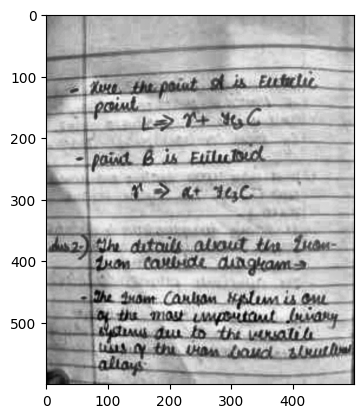

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_img(img: np.ndarray, show_plot: bool = True) -> None:
    if len(img.shape) == 3:
        img = img[:,:,::-1]  # Reverse BGR -> RGB
    plt.imshow(img)
    if show_plot:
        plt.show()

def channel_first_to_last(img_cf: np.ndarray) -> np.ndarray:
    return np.transpose(img_cf, (1, 2, 0))

def channel_last_to_first(img_cl: np.ndarray) -> np.ndarray:
    return np.transpose(img_cl, (2, 0, 1))

image = cv2.imread("random/notes.jpg")
image = cv2.resize(image, (500, 600))

image_bw = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=5, tileGridSize=(8, 8))
final_img = clahe.apply(image_bw)

by_channel_cl = np.copy(image)
by_channel_cf = channel_last_to_first(by_channel_cl)
for c in (0, 1, 2):
    by_channel_cf[c] = clahe.apply(by_channel_cf[c])

plot_img(image)
plt.imshow(image_bw, cmap='gray')
plt.show()

plot_img(by_channel_cl)
print(np.count_nonzero(by_channel_cl > 255))
print(by_channel_cl)
plt.imshow(final_img, cmap='gray')
plt.show()
